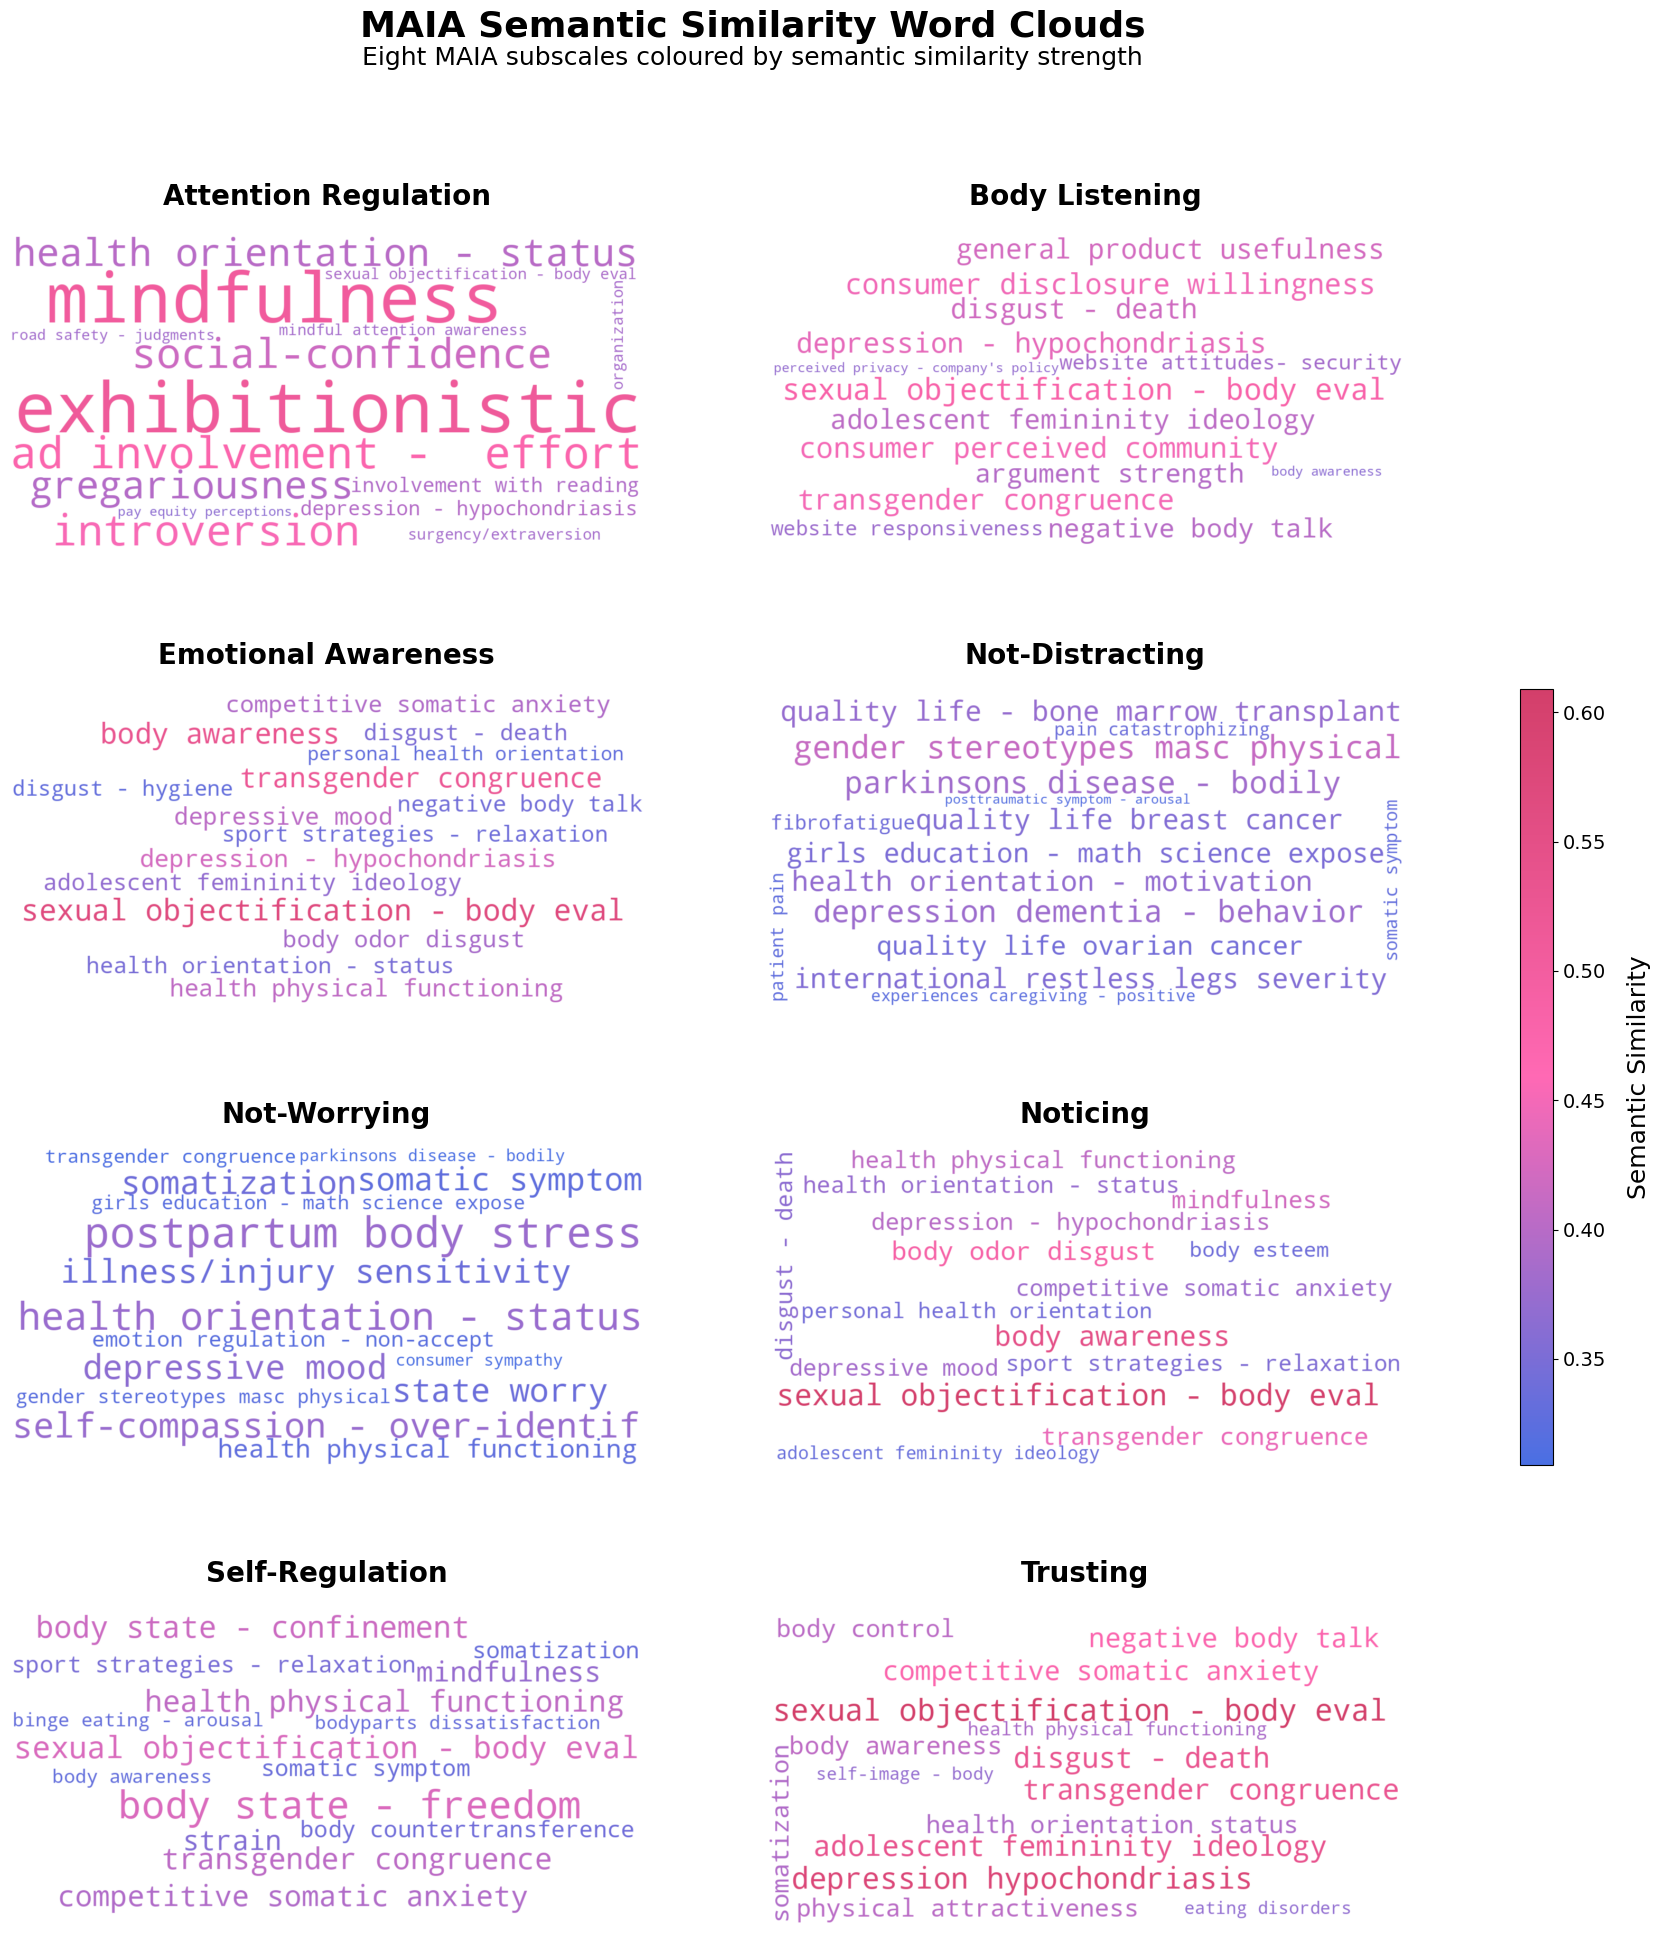

Saved merged figure to: /home/leah/Git/InteroMentalHealth/figures/Semantic_similarity_maia/MAIA_wordclouds_merged.png


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec

# -------------------------------
# Paths
# -------------------------------
input_folder = "/home/leah/Git/InteroMentalHealth/data/semantic_similarity/"
output_folder = "/home/leah/Git/InteroMentalHealth/figures/Semantic_similarity_maia/"
os.makedirs(output_folder, exist_ok=True)

merged_path = os.path.join(output_folder, "MAIA_wordclouds_merged.png")

# -------------------------------
# Colormap
# -------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_rpb", ["#4a6fe3", "HotPink", "#d33f6a"]
)

# -------------------------------
# Robust normalisation + title mapping
# -------------------------------
def camel_to_snake(s: str) -> str:
    # "BodyListening" -> "Body_Listening"
    return re.sub(r"(?<!^)(?=[A-Z])", "_", s)

def normalise_suffix(s: str) -> str:
    s = str(s)

    # strip common prefixes
    for prefix in ["semantic_similarity_", "semanticSimilarity_", "MAIA_", "MAIA2_", "maia_"]:
        s = s.replace(prefix, "")

    # standardise separators
    s = s.replace("-", "_").replace(" ", "_").strip("_")

    # if it’s camel case, convert to snake
    if "_" not in s and any(ch.isupper() for ch in s[1:]):
        s = camel_to_snake(s)

    # cleanup double underscores
    while "__" in s:
        s = s.replace("__", "_")

    return s.strip("_")

# Handle abbreviations/variants explicitly
TITLE_MAP = {
    # Common camel/snake variants you’re seeing in your figure
    "Atten_Regulation": "Attention Regulation",
    "Attention_Regulation": "Attention Regulation",

    "Body_Listening": "Body Listening",
    "BodyListening": "Body Listening",

    "Emotion_Awareness": "Emotional Awareness",
    "Emotional_Awareness": "Emotional Awareness",
    "EmotionAwareness": "Emotional Awareness",

    "Not_Distracting": "Not-Distracting",
    "NotDistracting": "Not-Distracting",

    "Not_Worrying": "Not-Worrying",
    "NotWorrying": "Not-Worrying",

    "Self_Regulation": "Self-Regulation",
    "SelfRegulation": "Self-Regulation",

    "Noticing": "Noticing",
    "Trusting": "Trusting",
}

# -------------------------------
# PASS 1: Load all data + global min/max
# -------------------------------
files = sorted([f for f in os.listdir(input_folder) if f.endswith(".csv")])
if len(files) == 0:
    raise FileNotFoundError(f"No .csv files found in {input_folder}")

all_infos = []
global_min = float("inf")
global_max = float("-inf")

for file in files:
    base = os.path.splitext(file)[0]

    # Make a normalised key for consistent title mapping
    suffix_key = normalise_suffix(base)
    display_title = TITLE_MAP.get(suffix_key, suffix_key)

    # Optional debug (uncomment once to verify keys)
    # print(f"{file} -> key='{suffix_key}' -> title='{display_title}'")

    df = pd.read_csv(os.path.join(input_folder, file))

    # Standardise columns
    if "Short_Name" in df.columns and "Similarity" in df.columns:
        df = df[["Short_Name", "Similarity"]].rename(columns={"Short_Name": "Scale"})
    else:
        df = df.rename(columns={df.columns[0]: "Scale", df.columns[1]: "Similarity"})[["Scale", "Similarity"]]

    # Clean labels
    df["Label"] = df["Scale"].astype(str).str.replace(r"\(.*?\)", "", regex=True).str.strip()
    df["Similarity"] = pd.to_numeric(df["Similarity"], errors="coerce")
    df = df.dropna(subset=["Similarity"])

    if df.empty:
        print(f"Warning: {file} has no valid similarity values after cleaning.")
        continue

    sims = df["Similarity"].to_numpy()
    global_min = min(global_min, float(np.min(sims)))
    global_max = max(global_max, float(np.max(sims)))

    all_infos.append({
        "file": file,
        "title_key": suffix_key,
        "title": display_title,
        "df": df
    })

if not all_infos:
    raise ValueError("No usable CSVs found (all empty after cleaning).")

norm = Normalize(vmin=global_min, vmax=global_max)

# -------------------------------
# Helper: build wordcloud + recolour by similarity
# -------------------------------
def build_wordcloud(df_sub, norm):
    frequencies = dict(zip(df_sub["Label"], df_sub["Similarity"]))

    def color_by_similarity(word, font_size, position, orientation, font_path, random_state):
        value = frequencies.get(word, 0)
        rgba = custom_cmap(norm(value))
        return "#{:02x}{:02x}{:02x}".format(
            int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255)
        )

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(frequencies)

    wc.recolor(color_func=color_by_similarity)
    return wc

# -------------------------------
# PASS 2: Generate + merge figure (spacing + smaller colourbar)
# -------------------------------
n = len(all_infos)
nrows, ncols = 4, 2

fig = plt.figure(figsize=(20, 22))

gs = GridSpec(
    nrows=nrows,
    ncols=ncols + 1,
    figure=fig,
    width_ratios=[1, 1, 0.05],
    wspace=0.25,
    hspace=0.45
)

axes = [fig.add_subplot(gs[r, c]) for r in range(nrows) for c in range(ncols)]

for i, info in enumerate(all_infos):
    if i >= len(axes):
        break
    ax = axes[i]

    wc = build_wordcloud(info["df"], norm)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")

    ax.set_title(
        info["title"],
        fontsize=20,
        fontweight="bold",
        pad=18
    )

# Turn off unused axes
for j in range(n, len(axes)):
    axes[j].axis("off")

# Smaller colourbar (middle rows only)
cax = fig.add_subplot(gs[1:3, -1])

sm = ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Semantic Similarity", fontsize=18, labelpad=15)
cbar.ax.tick_params(labelsize=14)
cbar.outline.set_linewidth(0.8)

# Global title + subtitle
fig.suptitle(
    "MAIA Semantic Similarity Word Clouds",
    fontsize=26,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5, 0.955,
    "Eight MAIA subscales coloured by semantic similarity strength",
    ha="center",
    fontsize=18
)

fig.savefig(merged_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved merged figure to: {merged_path}")
